# Bài tập cá nhân môn Trí tuệ nhận tạo UTH 2026

---

## Mục tiêu bài tập

- __Mô tả:__ Sử dụng Linear Regression để dự đoán giá của các căn nhà dựa trên các yếu tố như diện tích, số phòng, vị trí, v.v.

- __Dữ liệu:__ Tập dữ liệu có thể được thu thập từ các trang web bất động sản, từ cơ quan quản lý bất động sản hoặc từ các dịch vụ môi giới bất động sản. Dữ liệu này bao gồm các thông tin về các căn nhà như diện tích, số phòng, vị trí, tiện ích xung quanh và giá bán thực tế.

- __Yêu cầu:__

    1. __Tiền xử lý dữ liệu:__ Đọc và khám phá dữ liệu. Xử lý dữ liệu thiếu, loại bỏ nhiễu, chuẩn hóa dữ liệu nếu cần. Chọn các đặc trưng phù hợp cho mô hình Linear Regression.

    2. __Chia tập dữ liệu:__ Chia dữ liệu thành tập huấn luyện và tập kiểm tra.

    3. __Xây dựng mô hình Linear Regression:__ Sử dụng tập dữ liệu huấn luyện để xây dựng một mô hình Linear Regression.

    4. __Đánh giá mô hình:__ Sử dụng tập dữ liệu kiểm tra để đánh giá hiệu suất của mô hình Linear Regression trong việc dự đoán giá nhà.

    5. __Tinh chỉnh mô hình:__ Thử nghiệm với các tham số khác nhau của Linear Regression như hệ số điều chỉnh (alpha), số lượng đặc trưng, v.v. để cải thiện hiệu suất của mô hình.

    6. __Dự đoán:__ Sử dụng mô hình tốt nhất để dự đoán giá nhà cho các căn nhà mới.

---

## Pipeline Tổng quát áp dụng cho bài tập
1. Data collection & Understanding
2. Data Preprocessing
3. Data Splitting (Train / Validation / Test)
4. Model Selection & Training
5. Evaluation & Tuning
6. Deployment & Monitoring (Predict cho dữ liệu mới.)

---

## Machine Learning Pipeline
```mermaid
flowchart LR

    A([Dataset]) --> B["1. Data Collection<br/>& Understanding"]

    B --> C["2. Data Preprocessing"]

    C --> D["3. Data Splitting<br/>(Train / Validation / Test)"]

    D --> E["4. Model Selection<br/>& Training"]

    E --> F["5. Evaluation<br/>& Hyperparameter Tuning"]

    F -->|Performance đạt yêu cầu| G["6. Deployment & Monitoring"]

    G --> H([Predict New Data])

    F -->|Performance chưa đạt| C
```

---

## Các thuật toán sử dụng trong bài tập

1. __IQR (Interquartile Range) - Xử lý Outlier__

- Áp dụng cho các cột dữ liệu **Numerical**.
- Sử dụng khoảng tứ phân vị (Interquartile Range - IQR) để phát hiện các giá trị ngoại lai.
- Công thức:

  - __Q1: Phân vị 25%__
  - __Q3: Phân vị 75%__
  - __IQR = Q3 − Q1__

- Một giá trị được xem là Outlier nếu:

  - Giá trị < Q1 − 1.5 × IQR
  - Giá trị > Q3 + 1.5 × IQR

- Trong bài tập, các Outlier được loại bỏ nhằm giảm ảnh hưởng của các giá trị bất thường đến mô hình Linear Regression.

2. __Median Imputation - Xử lý Missing Values__

- Áp dụng cho các cột dữ liệu **Numerical** có giá trị bị thiếu.
- Giá trị thiếu được thay thế bằng **Median** của từng nhóm `Regionname`.
- Nếu một nhóm không đủ dữ liệu để tính Median, sẽ sử dụng Median của toàn bộ tập dữ liệu.

**Lý do lựa chọn Median:**

- Ít bị ảnh hưởng bởi Outlier hơn Mean.
- Phù hợp với các biến có phân phối lệch như:
  - BuildingArea
  - YearBuilt
  - Landsize

3. __One-Hot Encoding - Mã hóa dữ liệu Categorical__

- Áp dụng cho các cột dữ liệu **Categorical** như:
  - Suburb
  - Type
  - Method
  - Regionname
  - CouncilArea
  - SellerG
  - ...

- One-Hot Encoding chuyển mỗi giá trị phân loại thành một cột nhị phân (0 hoặc 1).

4. __StandardScaler - Chuẩn hóa dữ liệu__

- Áp dụng cho các cột dữ liệu **Numerical** sau khi xử lý Missing Values và Outlier.

- Công thức:

$$
z=\frac{x-\mu}{\sigma}
$$

Trong đó:

- $x$: giá trị gốc
- $\mu$: giá trị trung bình
- $\sigma$: độ lệch chuẩn

Sau khi chuẩn hóa:

- Mean ≈ 0
- Standard Deviation ≈ 1

**Lý do sử dụng StandardScaler:**

- Đưa các đặc trưng về cùng một thang đo.
- Giảm ảnh hưởng của sự khác biệt về đơn vị đo giữa các biến.
- Giúp quá trình huấn luyện mô hình Linear Regression ổn định và dễ hội tụ hơn.

---

## Kết quả cuối cùng
- Hiểu về mô hình Linear Regression
- Hiểu về Data Pipeline & Machine Learning Pipeline
- Tìm ra tham số tốt nhất để dự đoán giá bất động sản
- Phân tích đặc điểm giữa các Feature với Target là __giá nhà (Prices)__
- Trực quan hóa Các outlier, missing Value của features
- Dựa vào Correlation Matrix để Chọn các Feature quan trọng với Target và thực hiện Feature Engineering.
- Cover doan nghiệp phân tích thị trường bất động sản và xây dựng hoạnh định chiến lược.


In [312]:
# Data Loader
import pandas as pd
from datetime import datetime

# Data Preprocessing & Feature engineering
import math
import numpy as np
from src.IQR import remove_outliers_iqr
from src.Standard_Scaler import standard_scale

# EDA
from matplotlib import pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Evaluation & report
from src.evaluations import regression_report

## 1. Data collection & Understanding

Bộ Dữ liệu được thu thập trên [Kaggle](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) Chứa một file csv:

- **melb_data.csv**

### Bối cảnh Bộ dữ liệu.
- Thị trường bất động sản tại Melbourne đang phát triển `bùng nổ`.

### Mục tiêu
- Sử dụng thuật toán học có giám sát __Linear Regression__ để dự đoán giá bất động sản trong bộ dữ liệu

### Mô tả các biến trong bộ dữ liệu

| Biến              | Ý nghĩa                                                                       |
| ----------------- | ----------------------------------------------------------------------------- |
| **Suburb**        | Tên khu vực/quận nơi căn nhà tọa lạc.                                         |
| **Address**       | Địa chỉ cụ thể của căn nhà.                                                   |
| **Rooms**         | Số lượng phòng của bất động sản.                                              |
| **Price**         | Giá bán của bất động sản (đơn vị: đô la Úc - AUD).                            |
| **Method**        | Phương thức bán bất động sản.                                                 |
| **Type**          | Loại hình bất động sản.                                                       |
| **SellerG**       | Đại lý hoặc công ty môi giới bất động sản.                                    |
| **Date**          | Ngày giao dịch (ngày bán).                                                    |
| **Distance**      | Khoảng cách từ bất động sản đến khu trung tâm thương mại (CBD).               |
| **Regionname**    | Khu vực tổng quát của bất động sản (West, North West, North, North East,...). |
| **Propertycount** | Số lượng bất động sản hiện có trong khu vực (Suburb).                         |
| **Postcode**      | Mã bưu điện của khu vực.                                                      |
| **Bedroom2**      | Số phòng ngủ được thu thập từ một nguồn dữ liệu khác.                         |
| **Bathroom**      | Số lượng phòng tắm.                                                           |
| **Car**           | Số chỗ đậu xe hoặc gara.                                                      |
| **Landsize**      | Diện tích khu đất.                                                            |
| **Lattitude**     | Vĩ độ của vị trí căn nhà.                                                     |
| **Longtitude**    | Kinh độ của vị trí căn nhà.                                                   |
| **BuildingArea**  | Diện tích xây dựng của ngôi nhà.                                              |
| **CouncilArea**   | Hội đồng địa phương (chính quyền quản lý khu vực) nơi bất động sản tọa lạc.   |
| **YearBuilt**     | Năm xây dựng căn nhà.                                                         |

#### Những Feature quan trọng mà người dùng quan tâm nhất và ảnh hưởng đến biến Target (Prices)
- **YearBuilt**: Năm xây dựng căn nhà
- **Rooms**: Số lượng phòng của bất động
- **Car**: Số chỗ đậu xe hoặc gara.
- **Landsize**: Diện tích khu đất.
- **Suburb**: Tên khu vực/quận nơi căn nhà tọa lạc.
- **Distance**: Khoảng cách từ bất động sản đến khu trung tâm thương mại (CBD).
- **BuildingArea**: Diện tích xây dựng của ngôi nhà.


### Data Loader
> Tải dữ liệu từ file csv về Data Frame dùng thư viện pandas

In [313]:
df = pd.read_csv(r"D:\Nam 2\Trí tuệ nhân tạo\E-Learning UTH AI-EX-2026\BT cá nhân\data\melb_data.csv")

samples, features = df.shape

print(f'Sau khi Loader Data frame ta thu được dữ liệu raw ban đầu có: {samples} dòng (samples) và {features} cột (features)')

Sau khi Loader Data frame ta thu được dữ liệu raw ban đầu có: 13580 dòng (samples) và 21 cột (features)


In [314]:
print("5 mẫu đầu tiên trong Data Frame")
df.head()

5 mẫu đầu tiên trong Data Frame


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


### Data Validation
> Kiểm tra tính hợp lệ của dữ liệu Raw xem có đúng định dạng không, có cột nào chứa các giá trị vô lý không.

In [315]:
def validate_data(df):

    current_year = datetime.now().year

    rules = {
        "Rooms": lambda x: x.between(1, 20),
        "Price": lambda x: x > 0,
        "Distance": lambda x: x >= 0,
        "Postcode": lambda x: x.between(3000, 3999),
        "Bedroom2": lambda x: x.between(0, 20),
        "Bathroom": lambda x: x.between(0, 20),
        "Car": lambda x: x.between(0, 20),
        "Landsize": lambda x: x >= 0,
        "BuildingArea": lambda x: x >= 0,
        "YearBuilt": lambda x: x.between(1800, current_year),
        "Lattitude": lambda x: x.between(-39, -37),
        "Longtitude": lambda x: x.between(144, 146),
        "Propertycount": lambda x: x > 0,
    }

    report = []

    for col in df.columns:

        total = len(df)

        missing = df[col].isna().sum()

        if col in rules:

            valid = rules[col](df[col].dropna())

            invalid = (~valid).sum()

        else:
            invalid = 0

        valid_count = total - missing - invalid

        report.append({
            "Column": col,
            "Missing": missing,
            "Invalid": invalid,
            "Valid": valid_count,
            "Valid (%)": round(valid_count / total * 100, 2)
        })

    return pd.DataFrame(report)

validation_report = validate_data(df)

validation_report.style.background_gradient(
    subset=["Valid (%)"],
    cmap="RdYlGn"
)

,Column,Missing,Invalid,Valid,Valid (%)
0,Suburb,0,0,13580,100.000000
1,Address,0,0,13580,100.000000
2,Rooms,0,0,13580,100.000000
3,Type,0,0,13580,100.000000
4,Price,0,0,13580,100.000000
5,Method,0,0,13580,100.000000
6,SellerG,0,0,13580,100.000000
7,Date,0,0,13580,100.000000
8,Distance,0,0,13580,100.000000
9,Postcode,0,0,13580,100.000000


### Phân tích dữ liệu
> Thống kê đơn giản Raw data ban đầu chưa qua xử lý.

In [316]:
print("Thông tin Data Frame")
df.info()

Thông tin Data Frame
<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 

In [317]:
print("Mô tả Data Frame")
df.describe()

Mô tả Data Frame


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [318]:
# Phân tích các giá trị null/na, duplicate và missing value

def report_Data_Quanlity(df):
    record = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.count().values,
        'Missing Count': df.isnull().sum().values,
        'Missing (%)': np.round(df.isnull().mean().values * 100, 2),
        'Duplicate Rows': df.duplicated().sum()
    })
    
    return record

report_data = report_Data_Quanlity(df)

display(report_data)

,Column,Data Type,Non-Null Count,Missing Count,Missing (%),Duplicate Rows
0,Suburb,str,13580,0,0.00,0
1,Address,str,13580,0,0.00,0
2,Rooms,int64,13580,0,0.00,0
3,Type,str,13580,0,0.00,0
4,Price,float64,13580,0,0.00,0
5,Method,str,13580,0,0.00,0
6,SellerG,str,13580,0,0.00,0
7,Date,str,13580,0,0.00,0
8,Distance,float64,13580,0,0.00,0
9,Postcode,float64,13580,0,0.00,0


### 1.1 Data Clearning
> Xử lý các dữ liệu bị lỗi thiếu và trùng lặp.
> Xử lý Outlier (giá trị ngoại lai)
> Tập chung vào các giá trị hiện tại bị Missing sau đó đến Features quan trọng.

In [319]:
# Tạo một dữ liệu tạm thời
df_temp = df

# Xử lý dữ liệu Nan
df_temp = df_temp.dropna()

# Xử lý dữ liệu trùng lặp
df_temp = df_temp.drop_duplicates()

print(f"Dữ liệu sau khi xử lý qua Drop Duplicate và Drop Na: {df_temp.shape}")

Dữ liệu sau khi xử lý qua Drop Duplicate và Drop Na: (6196, 21)


> Sau khi xóa thẳng các dữ liệu bị missing (Nan/Null) và xóa trùng lặp (duplicates) thì từ số mẫu ban đầu là 13580 xuống thẳng còn 6196 hơn 50% là một tổn thất về mặt dữ liệu rất lớn và dữ liệu này được lưu ở DataFrame: `df_temp`
>
> Vì tổn thật quá lớn nên Ta phải xử lý các cột Missing Value này một cách thủ công vì các giá trị Outlier vẫn còn rất lớn theo bảng describe trước đó nên khi xử lý tiếp dữ liệu sẽ quá ít để training model. Nên ta phải xử lý các giá trị bị thiếu và giá trị ngoại lại thủ công.

In [320]:
# In các cột bị thiếu dữ liệu
missing_columns_report = report_data[report_data["Missing Count"] > 0]
print(missing_columns_report[["Column", "Data Type", "Missing Count", "Missing (%)"]])

          Column Data Type  Missing Count  Missing (%)
12           Car   float64             62         0.46
14  BuildingArea   float64           6450        47.50
15     YearBuilt   float64           5375        39.58
16   CouncilArea       str           1369        10.08


### Xử lí các cột thiếu dữ liệu Thủ công.
- Ta có 4 cột là [Car], [BuildingArea], [YearBuilt] và [CouncilArea]
    - Cột Car chỉ Missing có 0.46% $\rightarrow$ Drop luôn.
    - Cột BuildingArea Missing Tận 47.5%
    - Cột YearBuilt Missing Tận 39.58%
    - Cột CouncilArea Missing mức 10.08%

#### Xử lý cho cột Car
> Giá trị Missing $\rightarrow$ xóa thẳng vì chỉ có 0.46% để giữ độ sạch của dữ liệu.

In [321]:
df = df.dropna(subset=['Car'])

print(df.shape)

(13518, 21)


#### Xử lý cột BuildingArea
> Điền Median Vì Median ít bị ảnh hưởng bởi outlier. Có thể Điền theo Khu vực Suburb hoặc Regionname.

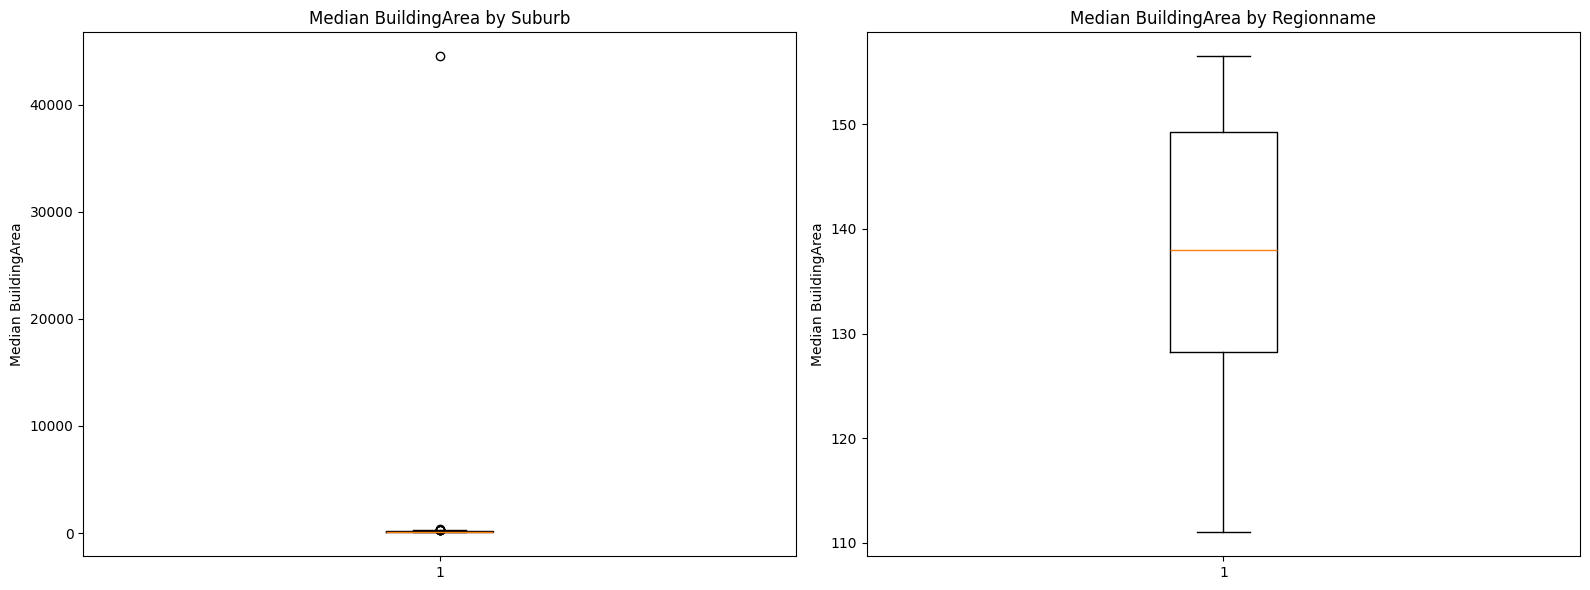

In [322]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Median theo Suburb
building_suburb = (
    df.groupby("Suburb")["BuildingArea"]
      .median()
      .dropna()
)

axes[0].boxplot(building_suburb)
axes[0].set_title("Median BuildingArea by Suburb")
axes[0].set_ylabel("Median BuildingArea")

# Median theo Regionname
building_region = (
    df.groupby("Regionname")["BuildingArea"]
      .median()
      .dropna()
)

axes[1].boxplot(building_region)
axes[1].set_title("Median BuildingArea by Regionname")
axes[1].set_ylabel("Median BuildingArea")

plt.tight_layout()
plt.show()

> Dựa vào biểu đồ ta thấy được nếu nhóm theo khu vực Regionname ta sẽ ít đụng phải outlier hơn nên ta sẽ điền fillna cho cột Suburb theo cột Regionname

In [323]:
# BuildingArea fillna theo Regionname

df["BuildingArea"] = (
    df.groupby("Regionname")["BuildingArea"]
      .transform(lambda x: x.fillna(x.median()))
)

print(df["BuildingArea"].isnull().sum())

0


#### Xử lý cột YearBuilt
> Điền Median Vì Median ít bị ảnh hưởng bởi outlier. Có thể Điền theo Khu vực Suburb hoặc Regionname.

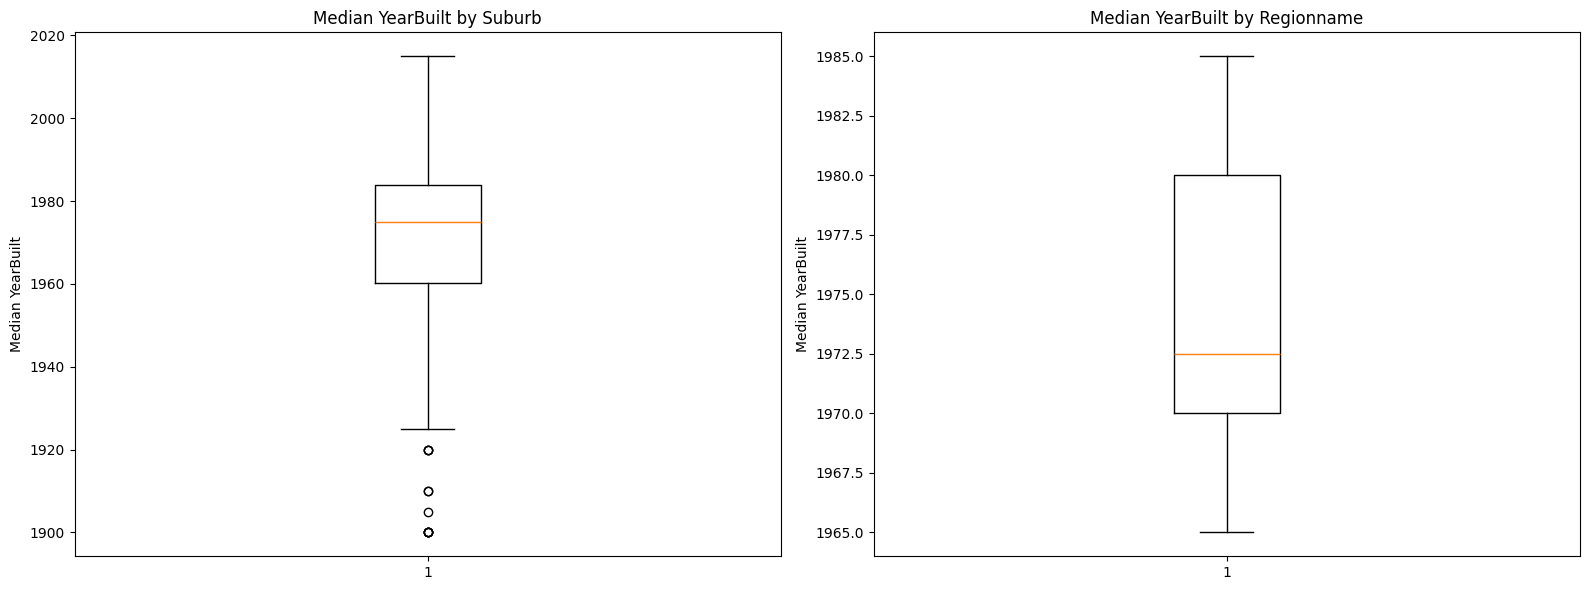

In [324]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Median theo Suburb
year_suburb = (
    df.groupby("Suburb")["YearBuilt"]
      .median()
      .dropna()
)

axes[0].boxplot(year_suburb)
axes[0].set_title("Median YearBuilt by Suburb")
axes[0].set_ylabel("Median YearBuilt")

# Median theo Regionname
year_region = (
    df.groupby("Regionname")["YearBuilt"]
      .median()
      .dropna()
)

axes[1].boxplot(year_region)
axes[1].set_title("Median YearBuilt by Regionname")
axes[1].set_ylabel("Median YearBuilt")

plt.tight_layout()
plt.show()

> Dựa vào biểu đồ ta thấy được nếu nhóm theo khu vực Regionname ta sẽ ít đụng phải outlier hơn nên ta sẽ điền fillna cho cột YearBuilt theo cột Regionname

In [325]:
# YearBuilt fillna theo Regionname

df["YearBuilt"] = (
    df.groupby("Regionname")["YearBuilt"]
      .transform(lambda x: x.fillna(x.median()))
)

print(df["YearBuilt"].isnull().sum())

0


#### Xử lý cột CouncilArea
> Điền "Unknown" vì đây là biến phân loại (categorical) để dùng One-Hot Encoding.

In [326]:
df["CouncilArea"] = df["CouncilArea"].fillna("Unknown")

print(df["CouncilArea"].isna().sum())

0


In [327]:
print("Số lượng các cột có giá trị Nan Trong Data Frame:")
print(df.isna().sum())

Số lượng các cột có giá trị Nan Trong Data Frame:
Suburb           0
Address          0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


### Xử lý các cột Outlier

- Chỉ xử lý cho Data Type Numerical

- Trực quan hóa Outlier dùng boxplot

- Có thể xử lý theo $IQR = Q_3 - Q_1$ (Trong đó: $Q_1$: dưới 25%, $Q_3$: Trên 75%).


In [328]:
numeric_cols = ["Price", "Distance", "Bedroom2", "Bathroom", "Car",
"Landsize", "BuildingArea", "YearBuilt", "Propertycount"]

In [329]:
# Tính giá trị ở các ngưỡng (10%, 25%, 50%, 75%, 90%) Cho mỗi cột trong numeric_cols
percentiles = df[numeric_cols].quantile([0.1,0.25,0.5,0.75,0.9,0.95,0.98]).T

display(percentiles)

,0.10,0.25,0.50,0.75,0.90,0.95,0.98
Price,480000.0,650000.0,901000.0,1328000.0,1850000.0,2290150.00,2873300.00
Distance,3.5,6.2,9.2,13.0,16.2,20.60,27.00
Bedroom2,2.0,2.0,3.0,3.0,4.0,4.00,5.00
Bathroom,1.0,1.0,1.0,2.0,2.0,3.00,3.00
Car,1.0,1.0,2.0,2.0,3.0,3.00,4.00
Landsize,0.0,178.0,442.5,651.0,802.0,994.15,1772.62
BuildingArea,83.0,111.0,130.0,147.0,193.0,245.00,316.66
YearBuilt,1925.0,1960.0,1970.0,1975.0,2005.0,2011.00,2013.00
Propertycount,2671.0,4380.0,6567.0,10331.0,14042.0,14949.00,21650.00


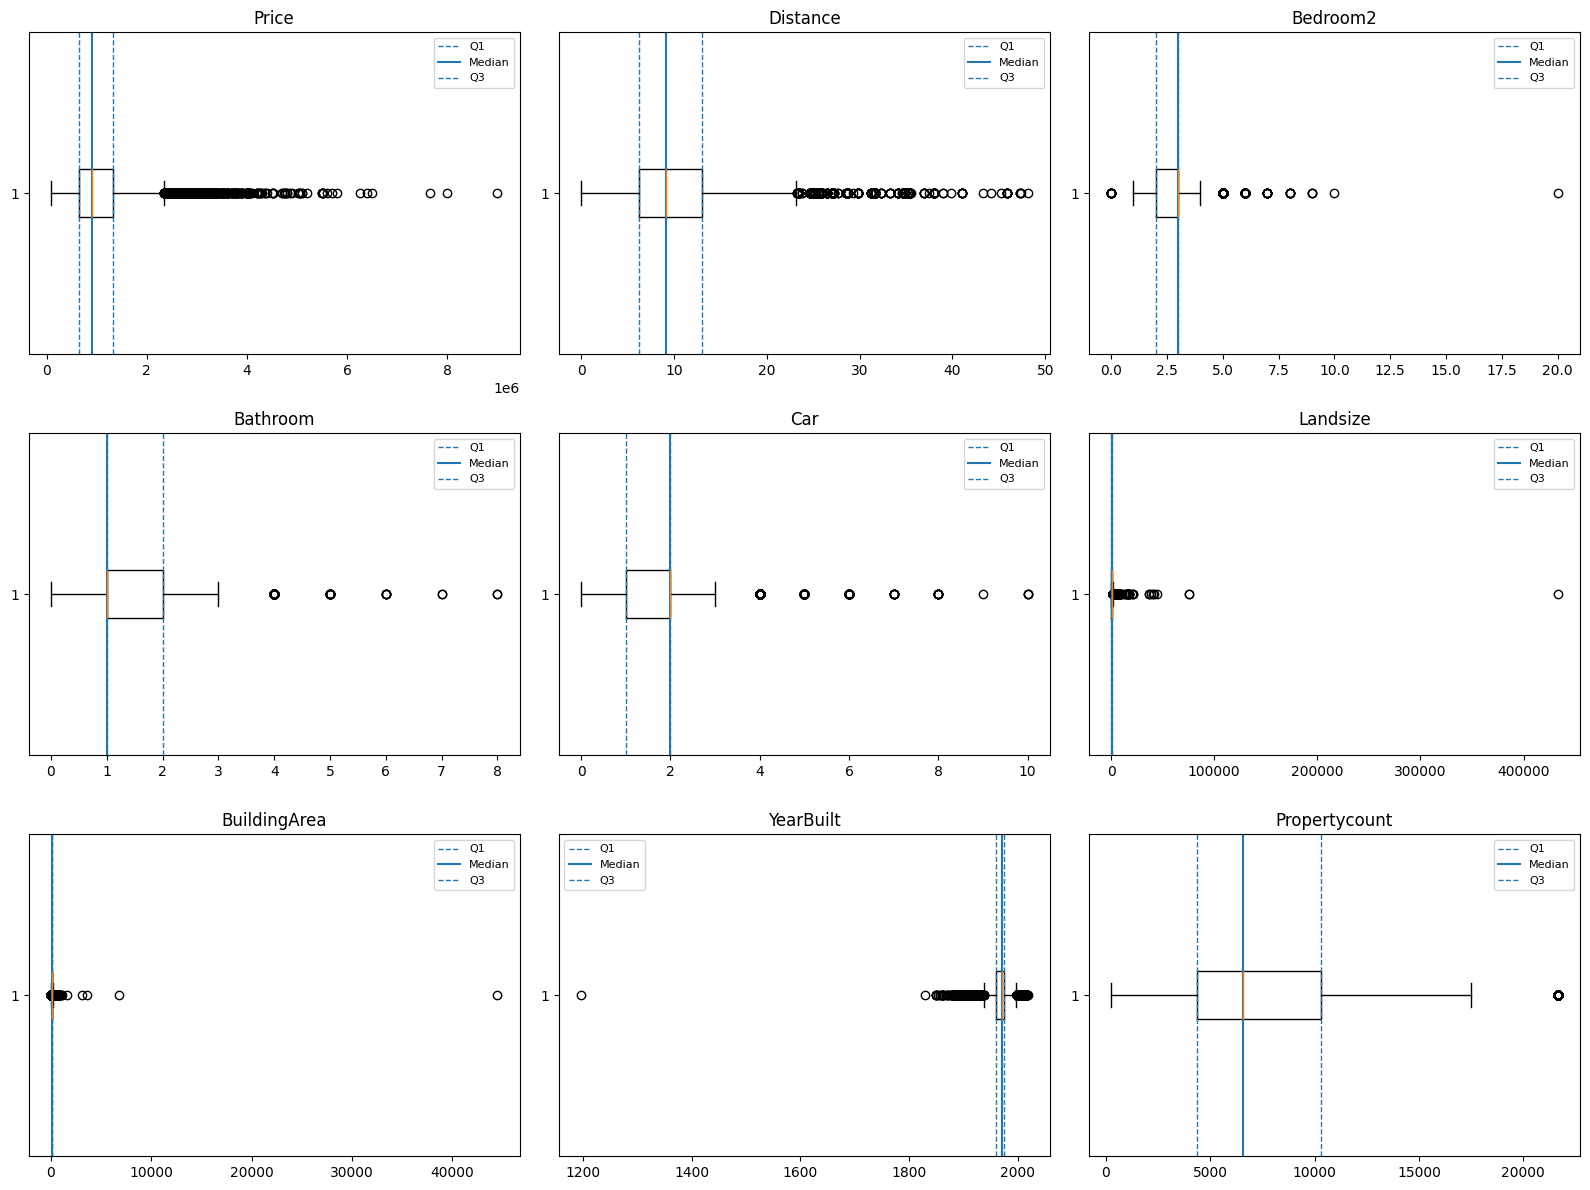

In [330]:
ncols = 3
nrows = math.ceil(len(numeric_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    data = df[col].dropna()

    q1 = data.quantile(0.25)
    q2 = data.quantile(0.50)
    q3 = data.quantile(0.75)

    axes[i].boxplot(data, vert=False)

    axes[i].set_title(col)

    # Vẽ các đường Q1 - Median - Q3
    axes[i].axvline(q1, linestyle="--", linewidth=1, label="Q1")
    axes[i].axvline(q2, linestyle="-", linewidth=1.5, label="Median")
    axes[i].axvline(q3, linestyle="--", linewidth=1, label="Q3")

    axes[i].legend(fontsize=8)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [331]:
df_Scaler = remove_outliers_iqr(df, numeric_cols)

    BÁO CÁO OUTLIERS CHO CỘT: Price
  Q1 (25th percentile)          : 650000.00
  Q3 (75th percentile)          : 1328000.00
  IQR (Interquartile Range)     : 678000.00
  Giới hạn dưới (Lower Limit)   : -367000.00
  Giới hạn trên (Upper Limit)   : 2345000.00
  Số dòng Đã xóa                : 621
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Distance
  Q1 (25th percentile)          : 6.20
  Q3 (75th percentile)          : 13.00
  IQR (Interquartile Range)     : 6.80
  Giới hạn dưới (Lower Limit)   : -4.00
  Giới hạn trên (Upper Limit)   : 23.20
  Số dòng Đã xóa                : 413
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Bedroom2
  Q1 (25th percentile)          : 2.00
  Q3 (75th percentile)          : 3.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : 0.50
  Giới hạn trên (Upper Limit)   : 4.50
  Số dòng Đã xóa                : 473
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Bat

> Ta thấy khi dùng IQR áp dụng hết cho các Feature nhất là Price, BuildingArea, Landsize và YearBuilt thì các giá trị Outlier lớn đã xóa phần lớn các giá trị quan trọng và tập chung dày đặc nên ta cần nới rộng các khoảng cận trên và dưới để tránh xóa các dữ liệu quan trọng.
>
> Ta có thể dựa vào biểu đồ ta phải đặt ra các mốc có thể chấp nhận được. Hoặc lựa chọn các Feature nên xóa và giữ lại những căn nhà có thể là biến động thật sự chứ không phải là nhiễu.

1. Các cột nên xử dụng hàm IQR để sử lý Outlier:
    - BuildingArea Nên nới rộng các khoảng ra để tránh xóa các dữ liệu quan trọng
    - Bathroom
    - Bedroom2
    - Car
    - Distance Có thể nới rộng IQR hơn

2. Không nên xóa hoặc xem xét biểu đồ box plot sau khi đã xử lý các cột trên trước:
    - Price Cần quan sát và chọn mức giá thủ công tránh quá lớn hoặc quá nhỏ
    - Landsize
    - Propertycount $\rightarrow$ Đây là thống kê khu vực, không nên xóa.
    - YearBuilt Nên dùng các mốc thời gian thay vì IQR

In [332]:
org_cols = ["Bedroom2", "Bathroom", "Car"]

square_cols = ["Distance", "BuildingArea"]

In [333]:
df = remove_outliers_iqr(df, org_cols)

df = remove_outliers_iqr(df, square_cols, factor=2.0)

# Chỉ lấy nhà có năm xây > năm 1800
df = df[(df['YearBuilt'] > 1800)].reset_index(drop=True)

    BÁO CÁO OUTLIERS CHO CỘT: Bedroom2
  Q1 (25th percentile)          : 2.00
  Q3 (75th percentile)          : 3.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : 0.50
  Giới hạn trên (Upper Limit)   : 4.50
  Số dòng Đã xóa                : 655
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Bathroom
  Q1 (25th percentile)          : 1.00
  Q3 (75th percentile)          : 2.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : -0.50
  Giới hạn trên (Upper Limit)   : 3.50
  Số dòng Đã xóa                : 54
----------------------------------------
    BÁO CÁO OUTLIERS CHO CỘT: Car
  Q1 (25th percentile)          : 1.00
  Q3 (75th percentile)          : 2.00
  IQR (Interquartile Range)     : 1.00
  Giới hạn dưới (Lower Limit)   : -0.50
  Giới hạn trên (Upper Limit)   : 3.50
  Số dòng Đã xóa                : 533
----------------------------------------
Tổng số dòng ban đầu : 13518
Số dòng còn lại      : 12276
Tổng số

In [334]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,11035.000000,1.103500e+04,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000,11035.000000
mean,2.756774,9.928470e+05,9.440770,3097.176801,2.735478,1.407612,1.418849,522.663163,123.346645,1965.790666,-37.806332,144.992011,7490.550430
std,0.785101,5.158326e+05,4.758758,69.091464,0.775559,0.557266,0.720507,4305.608817,28.048402,27.806878,0.070346,0.094696,4408.940649
min,1.000000,8.500000e+04,0.000000,3000.000000,1.000000,0.000000,0.000000,0.000000,49.000000,1830.000000,-38.027680,144.633020,389.000000
25%,2.000000,6.350000e+05,5.900000,3044.000000,2.000000,1.000000,1.000000,152.000000,111.000000,1960.000000,-37.854000,144.929255,4380.000000
50%,3.000000,8.700000e+05,9.000000,3081.000000,3.000000,1.000000,1.000000,354.000000,130.000000,1970.000000,-37.800600,144.996800,6567.000000
75%,3.000000,1.250000e+06,12.600000,3146.000000,3.000000,2.000000,2.000000,619.000000,130.000000,1970.000000,-37.756410,145.051900,10331.000000
max,6.000000,9.000000e+06,26.500000,3754.000000,4.000000,3.000000,3.000000,433014.000000,204.000000,2017.000000,-37.568570,145.330730,21650.000000


### 1.2 EDA
> Cái nhìn trực quan nhất về mối quan hệ giữa features và Target.

In [335]:
# Phân tích quan hệ giữa 3 thuộc tính quan trọng Price, BuildingArea và Rooms

groupby_report = df.groupby('Rooms').agg(
    Count=('Price', 'count'),                         # Số lượng căn nhà theo từng loại phòng
    Mean_Price=('Price', 'mean'),                     # Giá trung bình
    Median_Price=('Price', 'median'),                 # Giá trung vị (tránh sai lệch do outlier)
    Mean_Area=('BuildingArea', 'mean'),               # Diện tích trung bình
    Median_Area=('BuildingArea', 'median'),           # Diện tích trung vị
    Price_per_m2=('Price', lambda x: (x / df.loc[x.index, 'BuildingArea']).mean()) # Giá TB trên mỗi m2
).reset_index()

groupby_report = groupby_report.round({
    'Mean_Price': 2, 
    'Median_Price': 2, 
    'Mean_Area': 2, 
    'Median_Area': 2, 
    'Price_per_m2': 2
})

# Sắp xếp theo số phòng tăng dần
groupby_report = groupby_report.sort_values(by='Rooms')

display(groupby_report)

,Rooms,Count,Mean_Price,Median_Price,Mean_Area,Median_Area,Price_per_m2
0,1,511,452924.17,402000.0,101.58,111.0,5124.15
1,2,3506,769291.14,685000.0,106.66,111.0,7423.66
2,3,5202,1071649.00,955000.0,129.21,130.0,8383.42
3,4,1790,1348442.76,1229500.0,144.97,140.0,9604.59
4,5,24,1543004.17,1447500.0,138.88,130.0,11232.96
5,6,2,1012500.00,1012500.0,150.50,150.5,7308.93


Phương trình đường hồi quy: Price = 6319.38 * BuildingArea + 213372.34


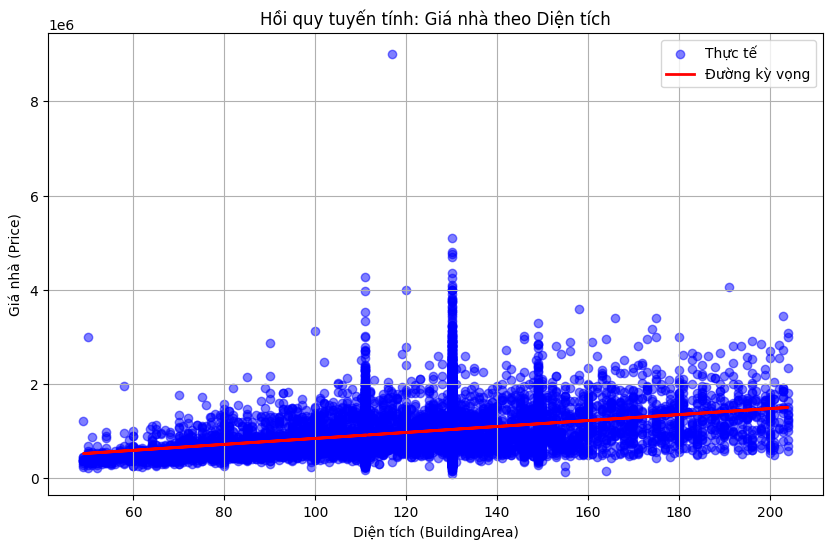

In [336]:
# EDA đơn giản và trực quan giữa giá nhà và diện tích căn nhà

# Vì cột BuildingArea của df raw ban đầu có giá trị Nan nên để minh họa ta dùng df đã drop.

X = df[["BuildingArea"]] # chuyển về mảng 2 chiều (100, 1) có 100 dòng và 1 cột rõ ràng theo quy định của sklearn
y = df["Price"]          # mảng 1 chiều (100, ) -> chỉ có chiều dọc không có chiều ngang.

# Huấn luyện mô hình để tìm đường hồi quy tuyến tính giữa Giá nhà và diện tích.
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]  # Hệ số góc Weight (w)
intercept = model.intercept_  # Hệ số chặn Bias (b)

print(f"Phương trình đường hồi quy: Price = {slope:.2f} * BuildingArea + {intercept:.2f}")

# Dự đoán giá nhà dựa trên diện tích
y_pred = model.predict(X)

# Vẽ biểu đồ trực quan
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế (Scatter)
plt.scatter(df["BuildingArea"], df["Price"], color="blue", alpha=0.5, label="Thực tế")

# Vẽ đường thẳng dự đoán (Regression Line)
plt.plot(df["BuildingArea"], y_pred, color="red", linewidth=2, label="Đường kỳ vọng")

plt.title("Hồi quy tuyến tính: Giá nhà theo Diện tích")
plt.xlabel("Diện tích (BuildingArea)")
plt.ylabel("Giá nhà (Price)")
plt.legend()
plt.grid(True)
plt.show()

> Qua hình ảnh hồi quy tuyến tính Giá nhà theo Diện tích. 
>
> Sau các nổ lực xử lý giá trị Outlier và Missing Value thì ta cũng đã có một hình dáng ban đầu của việc mô hình dự đoán dữ liệu qua đường thẳng lý tưởng màu đó.
>
> Dữ liệu tập chung dày đặc ở phân khúc diện tích từ 100 $m^2$ đến 150 $m^2$ và giá trị dày đặc ở mức 2 triệu (2e6).

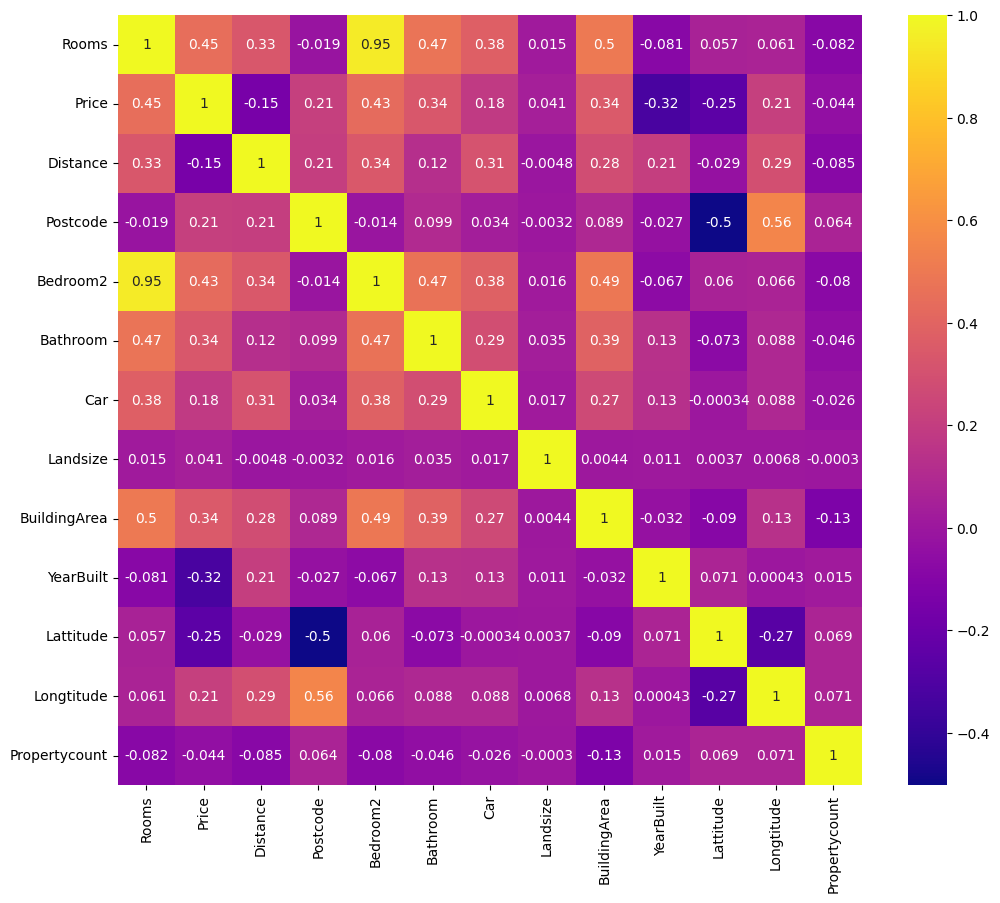

In [337]:
# Correlation Matrix để chọn các features tương quan mạnh với Target và giảm đa cộng tuyến.

plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='plasma')
plt.show()

## 2. Data Preprocessing
> Đưa dự liệu về dạng chuẩn để đưa vào model tránh Overfitting và Underfitting, Tránh mô hình bị 1 feature nào đó ảnh hưởng quá nhiều.
>
> Xử lý One-Hot Encoding cho Categorical
>
> Standard Scaler cho cột Numerical thay cho Min-Max Scaler để ít nhạy hơn với Outlier.

## 3. Data Splitting
> Tách dữ liệu ra các tập dữ liệu:
> - `Train`: 70% (Để huấn luyện Model)
> - `Test`: 25% (Để đánh giá Model)
> - `Val`: 5% (Để kiếm tra Model có đủ tốt trước khi đưa ra xử dụng trong thực tế.)

## 4. Model Selection & Training
> Xử dụng mô hình Linear Regression của thư viện Sklearn để Training Model dựa trên tập dữ liệu đã có.
>
> Quan sát Loss sau mỗi lần huấn luyện Model để đánh giá có học tốt hay không

## 5. Evaluation & Tuning
> Đánh giá Model đã huấn luyện dựa vào file `evaluation.py` đã viết trong folder `Src`
>
> Giải thích các chỉ số $MSE, RMSE, R^2, MAPE$
>
> Đánh giá cuối cùng trên đề thi (tập Val) để xem Model có thực sự tốt hay chỉ học vẹt.